In [1]:
import os
import zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from google.colab import files
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [3]:
!ls /content


dataset.zip  sample_data


In [4]:
zip_path = "/content/dataset.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# IMPORTANTE: apuntar a la carpeta interna
dataset_dir = "/content/dataset"

print("Contenido:", os.listdir(dataset_dir))

Contenido: ['BOLITA', 'RESORTE', 'OK', 'EMPAQUE']


In [5]:
class_names = ['BOLITA', 'EMPAQUE', 'OK', 'RESORTE']


In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(420, 420),
    batch_size=8
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(420, 420),
    batch_size=18
)

Found 259 files belonging to 4 classes.
Using 208 files for training.
Found 259 files belonging to 4 classes.
Using 51 files for validation.


In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.08, 0.08),
])

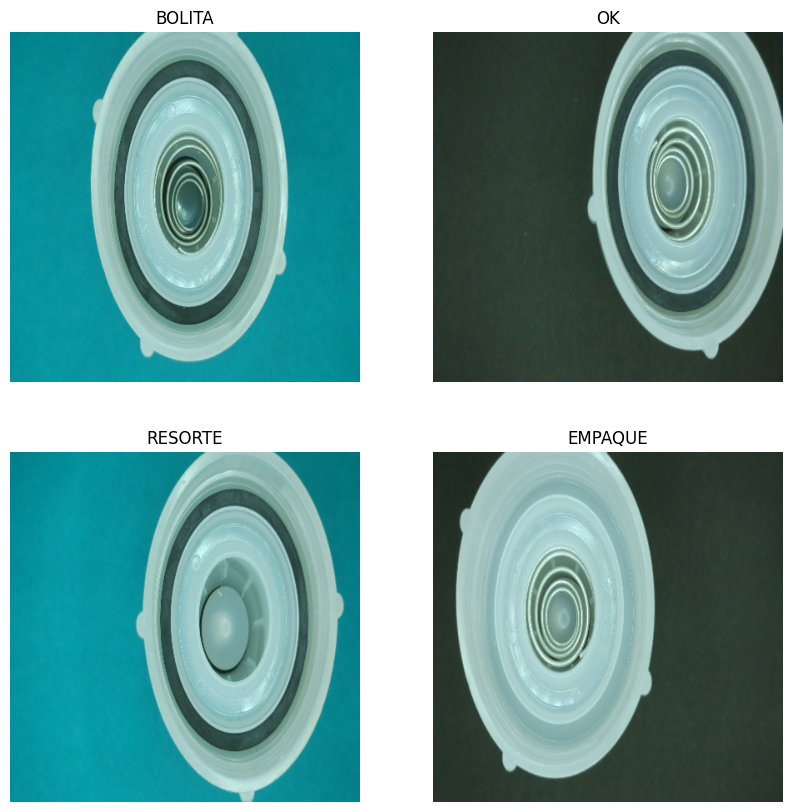

In [8]:


# Diccionario para guardar una imagen por clase
imagenes_por_clase = {}

for images, labels in train_ds:
    for i in range(len(images)):
        clase = class_names[labels[i]]

        if clase not in imagenes_por_clase:
            imagenes_por_clase[clase] = images[i].numpy().astype("uint8")

        # Cuando ya tenemos todas, salimos
        if len(imagenes_por_clase) == len(class_names):
            break
    if len(imagenes_por_clase) == len(class_names):
        break

# Mostrar
plt.figure(figsize=(10,10))

for i, clase in enumerate(imagenes_por_clase):
    plt.subplot(2,2,i+1)
    plt.imshow(imagenes_por_clase[clase])
    plt.title(clase)
    plt.axis("off")

plt.show()

In [9]:
print(train_ds.class_names)

['BOLITA', 'EMPAQUE', 'OK', 'RESORTE']


Label numérica: 0 -> nombre mostrado: BOLITA


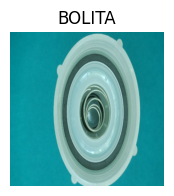

Label numérica: 2 -> nombre mostrado: OK


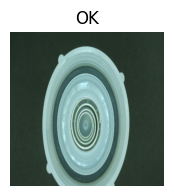

Label numérica: 0 -> nombre mostrado: BOLITA


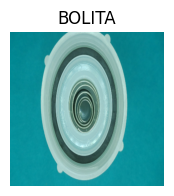

Label numérica: 3 -> nombre mostrado: RESORTE


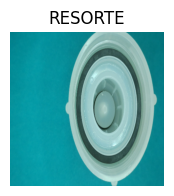

Label numérica: 0 -> nombre mostrado: BOLITA


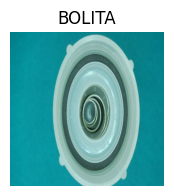

Label numérica: 0 -> nombre mostrado: BOLITA


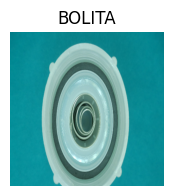

Label numérica: 2 -> nombre mostrado: OK


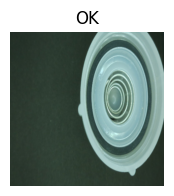

Label numérica: 0 -> nombre mostrado: BOLITA


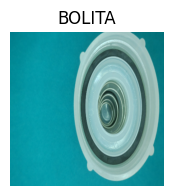

In [10]:
for images, labels in train_ds.take(1):
    for i in range(min(8, len(images))):
        print("Label numérica:", int(labels[i]), "-> nombre mostrado:", class_names[int(labels[i])])
        plt.figure(figsize=(2,2))
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
        plt.show()


In [11]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(420, 420, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False


/tmp/ipykernel_7686/2297802474.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.08, 0.08),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(420, 420, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=(420, 420, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(4, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

/tmp/ipykernel_7686/2265245239.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.4038 - loss: 1.2095 - val_accuracy: 0.4118 - val_loss: 1.0657
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.5769 - loss: 0.9667 - val_accuracy: 0.8627 - val_loss: 0.8186
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7019 - loss: 0.7957 - val_accuracy: 0.9804 - val_loss: 0.6649
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.8125 - loss: 0.6587 - val_accuracy: 0.9804 - val_loss: 0.5418
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.9279 - loss: 0.5691 - val_accuracy: 1.0000 - val_loss: 0.4608
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.9231 - loss: 0.4903 - val_accuracy: 1.0000 - val_loss: 0.3970
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.9615 - loss: 0.4217 - val_accuracy: 1.0000 - val_loss: 0.3416
Epoch 8/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.9760 - loss: 0.3772 - val_accuracy: 1.0000 - val_loss:

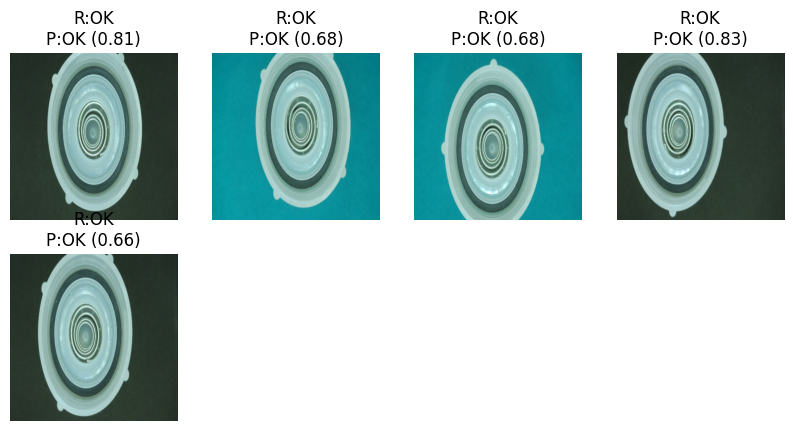

In [17]:


# ===== CONFIGURACIÓN =====
clase_a_ver = "OK"   # 'OK', 'EMPAQUE', 'RESORTE', 'BOLITA'
num_imagenes = 5    # cuántas quieres ver

# =========================

contador = 0

plt.figure(figsize=(10,10))

for images, labels in val_ds:
    for i in range(len(images)):
        nombre_clase = class_names[int(labels[i])]

        if nombre_clase == clase_a_ver:
            img = images[i].numpy()

            pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
            pred_class = np.argmax(pred)
            confidence = np.max(pred)

            plt.subplot(4,4,contador+1)
            plt.imshow(img.astype("uint8"))
            plt.title(f"R:{nombre_clase}\nP:{class_names[pred_class]} ({confidence:.2f})")
            plt.axis("off")

            contador += 1

            if contador >= num_imagenes:
                break

    if contador >= num_imagenes:
        break

plt.show()

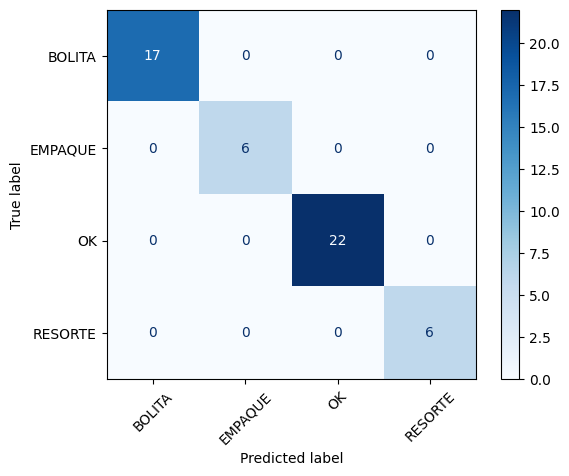

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()